In [1]:
import pandas as pd
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad



In [76]:
pretrain = ad.read_h5ad("/home/kchen/microbiome/gut_microbiome_GPT/datasets/hmc_final/pretrain.h5ad")
dtrain = ad.read_h5ad("/home/kchen/microbiome/gut_microbiome_GPT/datasets/hmc_final/downstream_train.h5ad")
dtest = ad.read_h5ad("/home/kchen/microbiome/gut_microbiome_GPT/datasets/hmc_final/downstream_test.h5ad")

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [77]:
print(pretrain, dtrain, dtest)

AnnData object with n_obs × n_vars = 106469 × 1514
    obs: 'drr', 'study_id', 'region', 'total_bases', 'instrument'
    var: 'taxa'
    varm: 'taxonomy' AnnData object with n_obs × n_vars = 23511 × 1514
    obs: 'drr', 'study_id', 'region', 'total_bases', 'instrument', 'downstream_task', 'categorical_label', 'continuous_label'
    varm: 'taxonomy' AnnData object with n_obs × n_vars = 6090 × 1514
    obs: 'drr', 'study_id', 'region', 'total_bases', 'instrument', 'downstream_task', 'categorical_label', 'continuous_label'
    varm: 'taxonomy'


In [3]:
dtest.varm["taxonomy"]

,Domain,Phylum,Class,Order,Family,Genus
Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Atopobiaceae.Tractidigestivibacter,Bacteria,Actinomycetota,Coriobacteriia,Coriobacteriales,Atopobiaceae,Tractidigestivibacter
Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Coriobacteriaceae.Collinsella,Bacteria,Actinomycetota,Coriobacteriia,Coriobacteriales,Coriobacteriaceae,Collinsella
Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia,Bacteria,Actinomycetota,Coriobacteriia,Coriobacteriales,Eggerthellaceae,Adlercreutzia
Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Senegalimassilia,Bacteria,Actinomycetota,Coriobacteriia,Coriobacteriales,Eggerthellaceae,Senegalimassilia
Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.Holdemanella,Bacteria,Bacillota,Bacilli,Erysipelotrichales,Erysipelotrichaceae,Holdemanella
...,...,...,...,...,...,...
Bacteria.Marinimicrobia (SAR406 clade).Incertae Sedis.Incertae Sedis.Incertae Sedis.Incertae Sedis,Bacteria,Marinimicrobia (SAR406 clade),Incertae Sedis,Incertae Sedis,Incertae Sedis,Incertae Sedis
Bacteria.Balneolota.Balneolia.Balneolales.Balneolaceae.Balneola,Bacteria,Balneolota,Balneolia,Balneolales,Balneolaceae,Balneola
Bacteria.Pseudomonadota.Gammaproteobacteria.Thiomicrospirales.Thiomicrospiraceae.Thiomicrospira,Bacteria,Pseudomonadota,Gammaproteobacteria,Thiomicrospirales,Thiomicrospiraceae,Thiomicrospira
Bacteria.Bacteroidota.Bacteroidia.Flavobacteriales.Crocinitomicaceae.Brumimicrobium,Bacteria,Bacteroidota,Bacteroidia,Flavobacteriales,Crocinitomicaceae,Brumimicrobium


In [4]:
X = dtest.X

taxonomy = dtest.varm["taxonomy"]

# 1️⃣ Identify columns belonging to each genus
bacteroides_mask = taxonomy["Genus"] == "Bacteroides"
faecali_mask = taxonomy["Genus"] == "Faecalibacterium"

# Total abundance per sample
bacteroides_vars = np.where(bacteroides_mask)[0]
faecali_vars = np.where(faecali_mask)[0]

total = X.sum(axis=1)
bact = X[:, bacteroides_vars].sum(axis=1)
faec = X[:, faecali_vars].sum(axis=1)

# Avoid divide-by-zero
total = np.clip(total, 1e-8, None)

bact_prop = bact / total
faec_prop = faec / total

has_bact = (bact_prop > 0.05) & (bact_prop < 0.3)
has_faec = (faec_prop > 0.17) & (faec_prop < 0.2)


keep_samples = has_bact & has_faec

dtest_filtered = dtest[keep_samples].copy()

print(f"Kept {keep_samples.sum()} samples")

Kept 128 samples


/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
dtest_filtered.obs['study_id']

sample
PRJEB5729_ERR444058          PRJEB5729
PRJEB5729_ERR443862          PRJEB5729
PRJEB5729_ERR443898          PRJEB5729
PRJEB5729_ERR444115          PRJEB5729
PRJEB5729_ERR444295          PRJEB5729
                              ...     
PRJNA428736_SRR6444182     PRJNA428736
PRJNA428736_SRR6444087     PRJNA428736
PRJDB10485_DRR243930        PRJDB10485
PRJDB10485_DRR243847        PRJDB10485
PRJNA650259_SRR12377168    PRJNA650259
Name: study_id, Length: 128, dtype: category
Categories (6, object): ['PRJDB10485', 'PRJEB5729', 'PRJNA428736', 'PRJNA516932', 'PRJNA559143', 'PRJNA650259']

In [137]:
dtest_filtered.write_h5ad("/home/kchen/microbiome/gut_microbiome_GPT/data/conference/pathway.h5ad")

In [6]:
dtest_filtered = ad.read_h5ad("/home/kchen/microbiome/gut_microbiome_GPT/data/conference/pathway.h5ad")

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
import os
from pathlib import Path
import sys

In [11]:
# Go up two levels to project root
project_root = Path.cwd().parents[0]   # = .../gut_microbiome_GPT
# or: project_root = Path.cwd().parent

sys.path.insert(0, str(project_root))

In [ ]:
import sys
from pathlib import Path
# Go up two levels to project root
project_root = Path.cwd().parents[0]   # = .../gut_microbiome_GPT
# or: project_root = Path.cwd().parent

sys.path.insert(0, str(project_root))
from data_utils import TaxaVocabulary

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
import torch
embeddings_dict = torch.load('/home/kchen/microbiome/gut_microbiome_GPT/outputs/eval_pathway/pathway_dict.pt')
vocab = TaxaVocabulary.load('/home/kchen/microbiome/gut_microbiome_GPT/outputs/pretrain_mask_gnn/taxa_vocab.pkl')

In [15]:
X = dtest_filtered.X  # (20, 1514) could be np array or sparse
X.shape

(128, 1514)

In [16]:
embeddings_dict['taxa_ids'].shape

torch.Size([20, 200])

In [17]:
outputs = embeddings_dict['outputs'][:,1:,:]

In [18]:
outputs.shape

torch.Size([20, 200, 128])

Color scale (log1p): vmin=1.099, vmax=8.895


/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


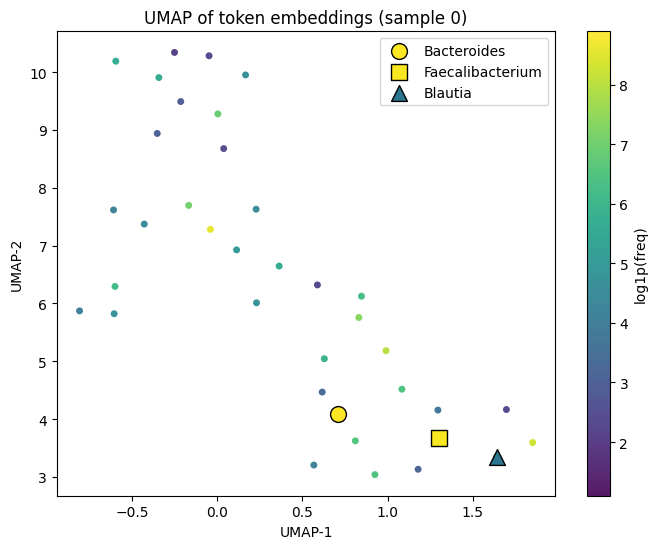

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


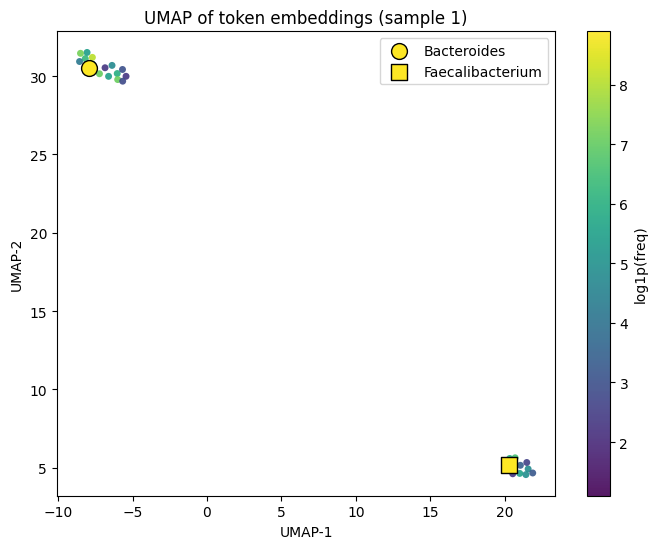

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


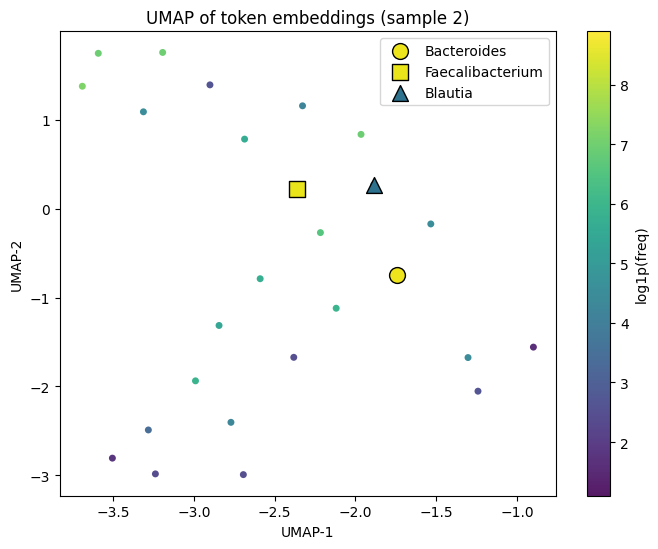

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


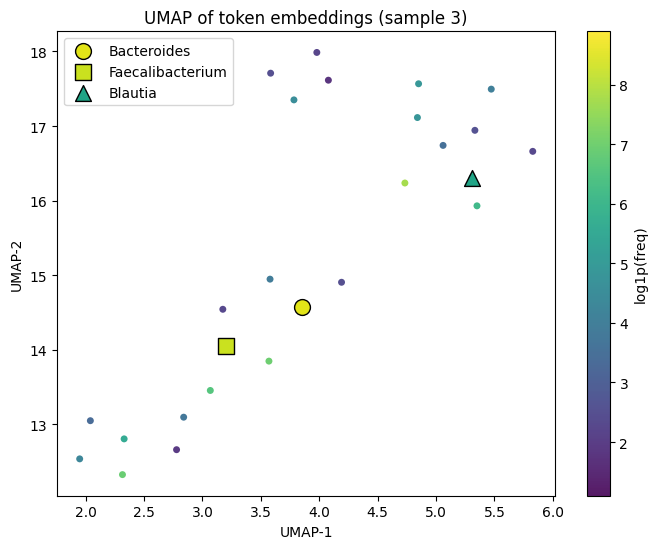

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


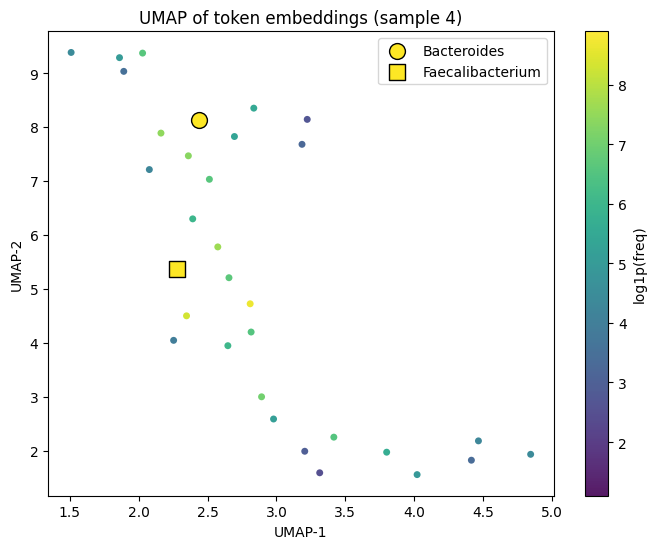

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_49389/2898197409.py:104: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


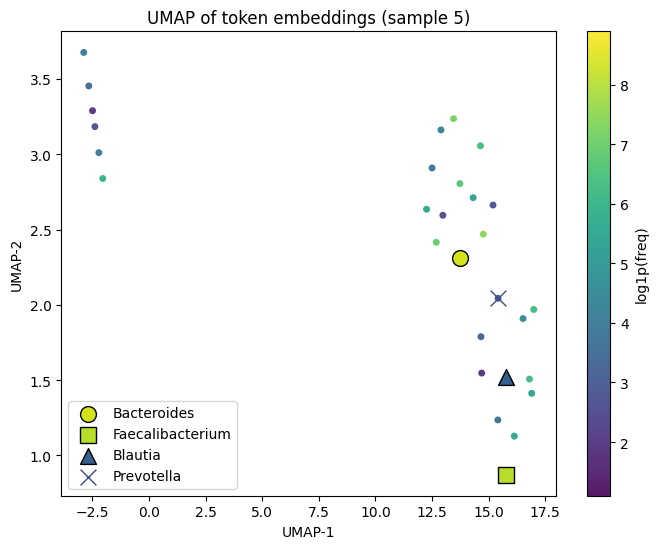

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


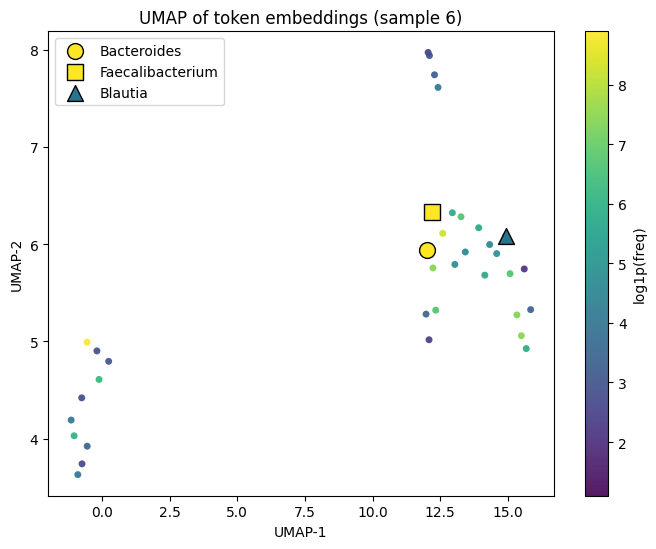

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_49389/2898197409.py:104: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


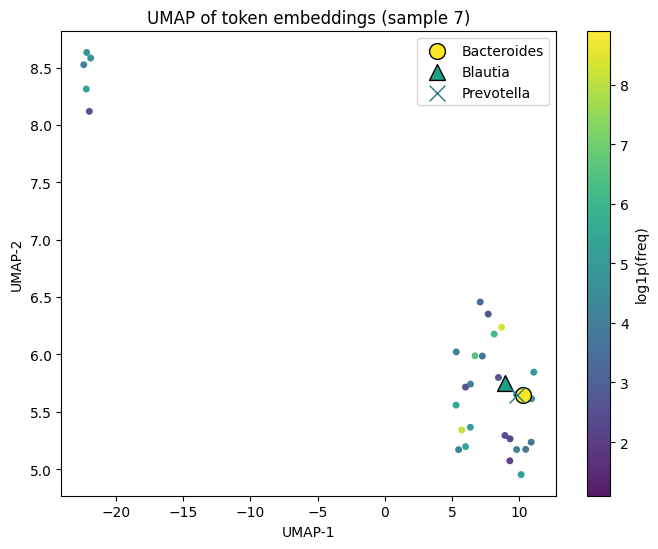

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


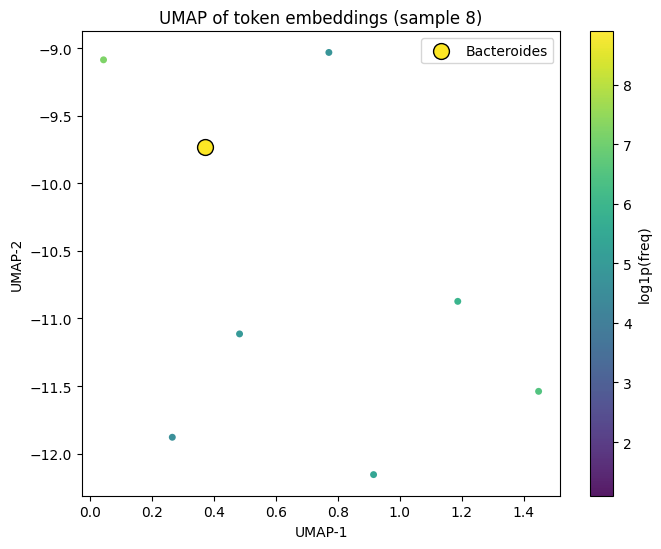

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


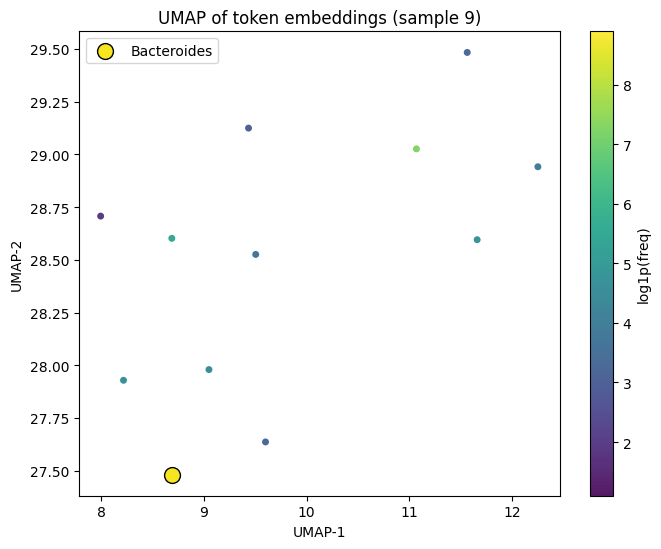

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_49389/2898197409.py:104: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


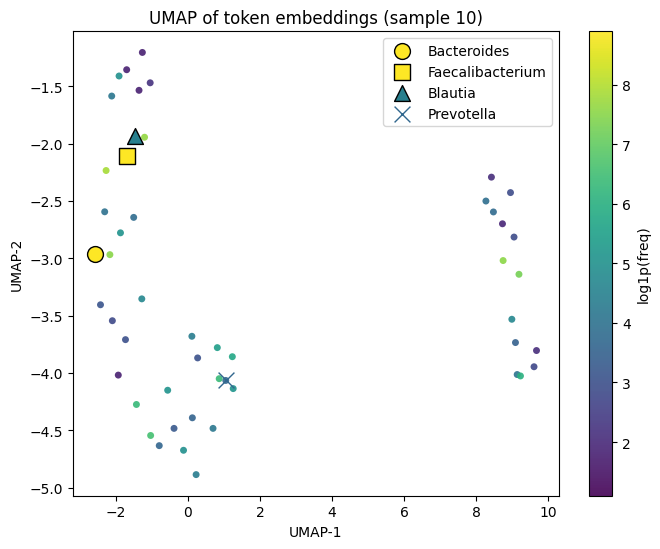

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


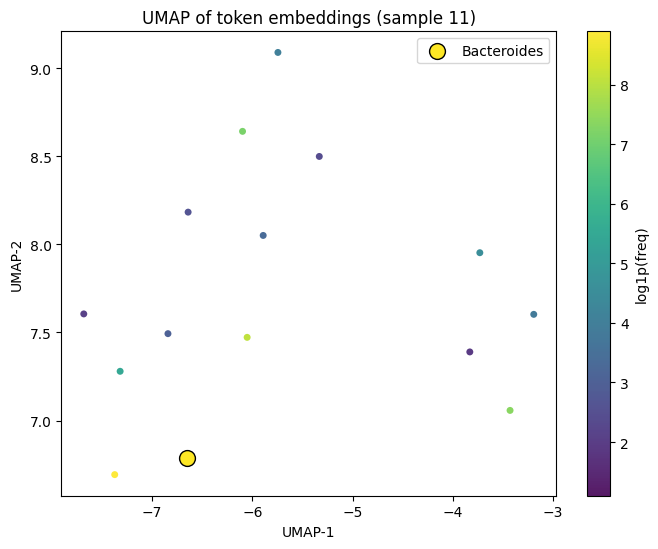

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


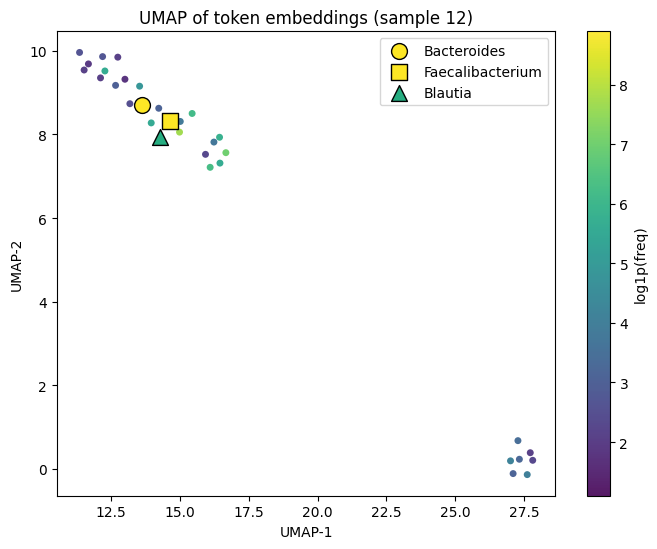

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


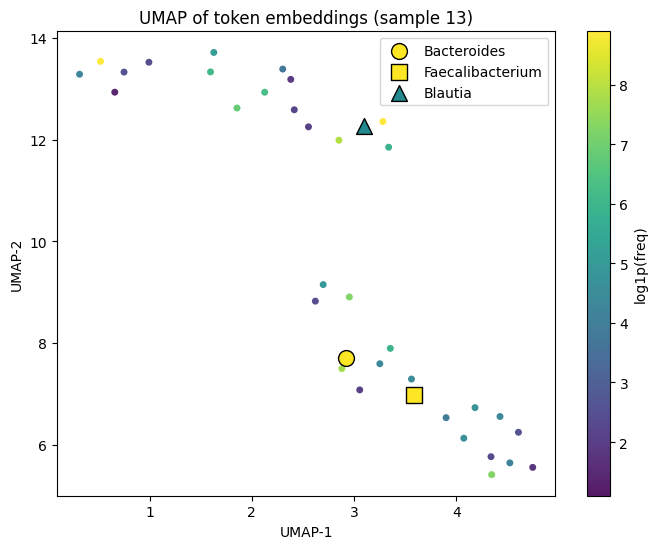

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


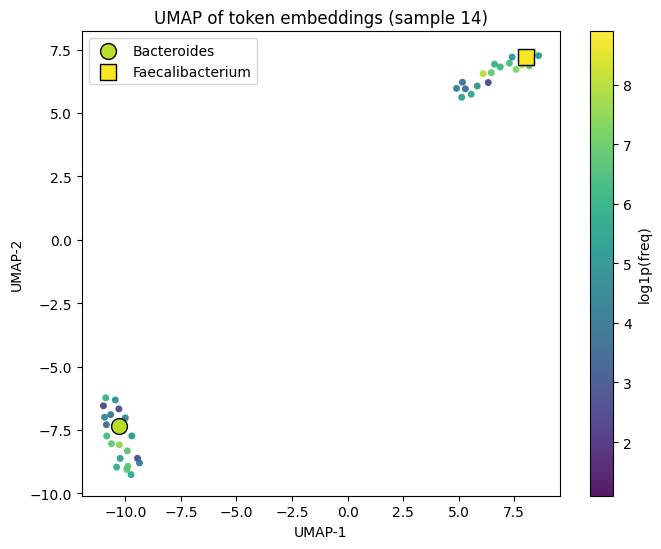

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


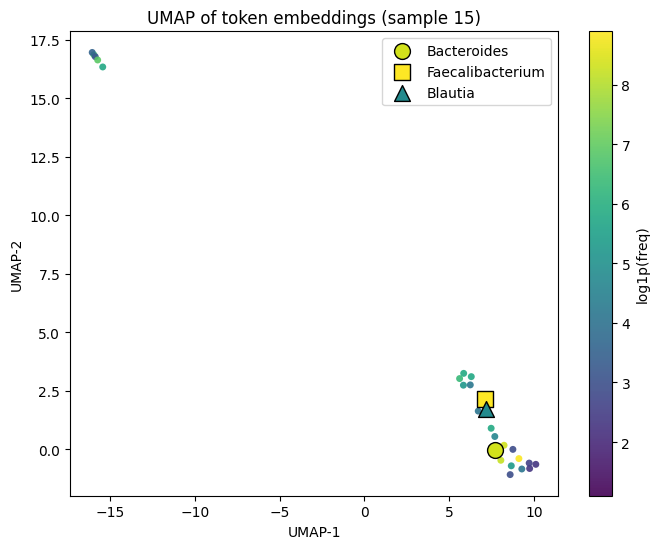

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


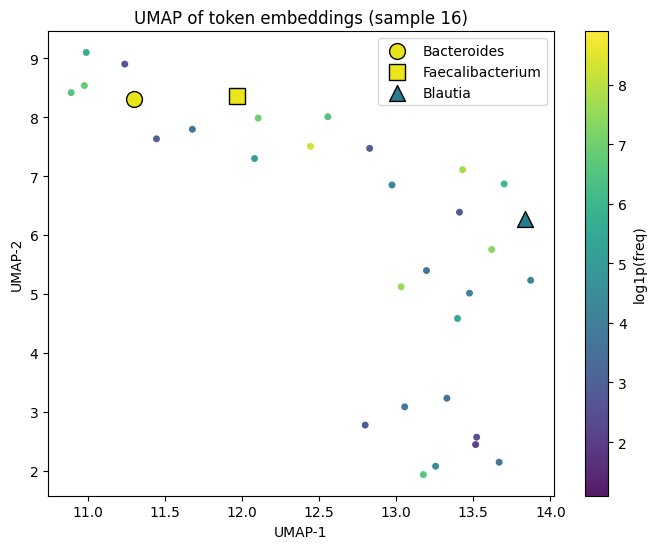

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_49389/2898197409.py:104: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


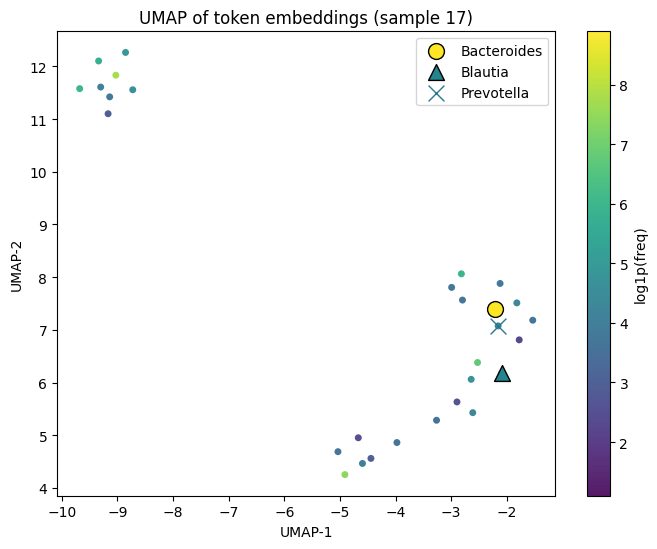

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


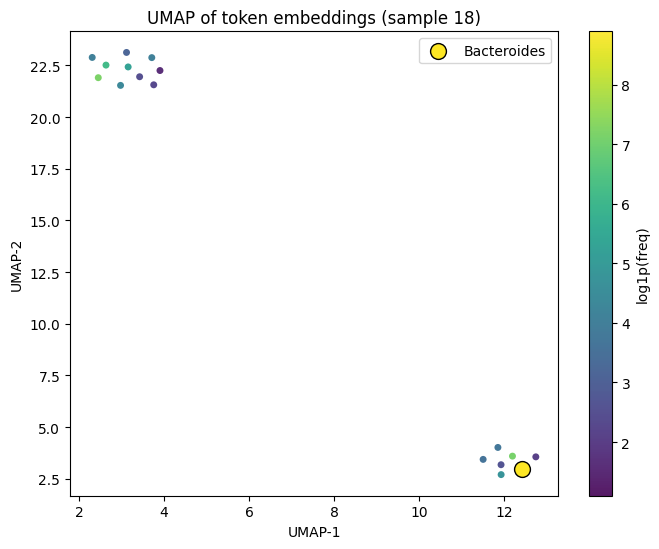

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


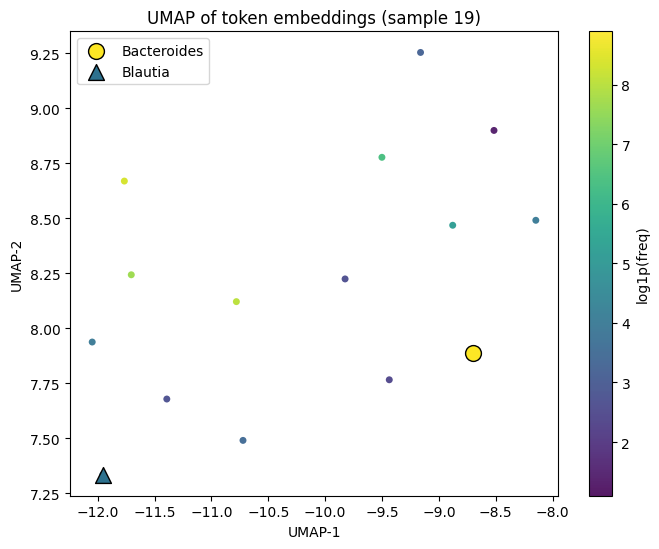

IndexError: index 20 is out of bounds for dimension 0 with size 20

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import umap

# ----- Prepare X -----
X = dtest_filtered.X
if hasattr(X, "toarray"):
    X_dense = X.toarray()
else:
    X_dense = np.asarray(X)

num_taxa = X_dense.shape[1]

markers = {
    "Bacteroides": "o",        # circle
    "Faecalibacterium": "s",   # square
    "Blautia": "^",         # triangle
    "Prevotella": "x"
}

bacteroides_mask = taxonomy["Genus"] == "Bacteroides"
faecali_mask = taxonomy["Genus"] == "Faecalibacterium"
blautia_mask = taxonomy["Genus"] == "Blautia"

bmask = np.asarray(bacteroides_mask).astype(bool)
fmask = np.asarray(faecali_mask).astype(bool)
blmask = np.asarray(blautia_mask).astype(bool)
pmask = np.asarray(taxonomy["Genus"] == "Prevotella").astype(bool)

# ----- Shared color normalization -----
use_log = True
X_for_scale = np.log1p(X_dense) if use_log else X_dense

vmin, vmax = np.nanpercentile(X_for_scale[X_for_scale > 0], [1, 99])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis

print(f"Color scale ({'log1p' if use_log else 'raw'}): vmin={vmin:.4g}, vmax={vmax:.4g}")

# ----- Loop through samples -----
for sample_idx in range(X_dense.shape[0]):
# for sample_idx in range(15, 16):

    taxa_ids = embeddings_dict["taxa_ids"][sample_idx].detach().cpu().numpy().astype(int)
    E = outputs[sample_idx].detach().cpu().numpy()

    L = taxa_ids.shape[0]
    row = X_dense[sample_idx]
    row = np.log1p(row) if use_log else row

    # valid taxa indices
    valid = (taxa_ids >= 0) & (taxa_ids < num_taxa)

    # frequency aligned to tokens
    freq = np.zeros(L)
    freq[valid] = row[taxa_ids[valid]]

    # ---- FILTER OUT ZERO FREQUENCY ----
    nonzero = valid & (freq > 0)

    if np.sum(nonzero) == 0:
        print(f"Sample {sample_idx}: no nonzero taxa, skipping.")
        continue

    # labels
    labels = np.full(L, "none", dtype=object)
    labels[nonzero & bmask[taxa_ids]] = "Bacteroides"
    labels[nonzero & fmask[taxa_ids]] = "Faecalibacterium"
    labels[nonzero & blmask[taxa_ids]] = "Blautia"
    labels[nonzero & pmask[taxa_ids]] = "Prevotella"

    # UMAP only on remaining tokens
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=0,
    )

    Z = reducer.fit_transform(E[nonzero])

    freq_plot = freq[nonzero]
    labels_plot = labels[nonzero]

    plt.figure(figsize=(7, 5.6))

    # Base scatter
    sc = plt.scatter(
        Z[:, 0], Z[:, 1],
        c=freq_plot,
        s=25,
        alpha=0.9,
        cmap=cmap,
        norm=norm,
        linewidths=0
    )

    # Highlight bacteroides

    for s, marker in markers.items():
        m_b = labels_plot == s
        if np.any(m_b):
            plt.scatter(
                Z[m_b, 0], Z[m_b, 1],
                c=freq_plot[m_b],
                s=130,
                cmap=cmap,
                norm=norm,
                marker=marker,
                edgecolors="black",
                linewidths=1.0,
                zorder=3,
                label=s
            )

    plt.title(f"UMAP of token embeddings (sample {sample_idx})")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

    plt.legend()

    cb = plt.colorbar(sc)
    cb.set_label("log1p(freq)" if use_log else "freq")

    plt.tight_layout()
    plt.show()


In [51]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.cluster import DBSCAN, KMeans

def cluster_and_plot_one_sample(
    outputs,
    embeddings_dict,
    vocab,
    bacteroides_mask,
    faecali_mask,
    sample_idx: int,
    eps: float = 0.6,
    min_samples: int = 5,
    X=None,                 # optional: dtest_filtered.X (20 x 1514)
    drop_zero_count: bool = False,
    use_log_freq: bool = True,
):
    """
    Cluster token embeddings for a single sample using UMAP -> DBSCAN and plot.

    If X is provided and drop_zero_count=True, tokens whose taxa count is 0 in
    that sample are removed before UMAP/DBSCAN.
    """

    # ---- extract sample ----
    taxa_ids = embeddings_dict["taxa_ids"][sample_idx].detach().cpu().numpy().astype(int)  # (L,)
    E = outputs[sample_idx].detach().cpu().numpy()                                        # (L, d)

    bmask = np.asarray(bacteroides_mask).astype(bool)
    fmask = np.asarray(faecali_mask).astype(bool)

    num_taxa = len(bmask)
    valid = (taxa_ids >= 0) & (taxa_ids < num_taxa)

    # ---- optional: drop zero-count taxa tokens using X ----
    keep = valid.copy()
    freq = None
    if drop_zero_count:
        if X is None:
            raise ValueError("drop_zero_count=True requires X (e.g., dtest_filtered.X).")
        X_dense = X.toarray() if hasattr(X, "toarray") else np.asarray(X)
        row = X_dense[sample_idx]  # (num_taxa,)
        row = np.log1p(row) if use_log_freq else row

        freq = np.full_like(taxa_ids, np.nan, dtype=float)
        freq[valid] = row[taxa_ids[valid]]
        keep = valid & (freq > 0)

        if keep.sum() == 0:
            raise ValueError(f"Sample {sample_idx}: no nonzero-count taxa tokens to plot.")

    # Apply keep-mask
    taxa_ids_k = taxa_ids[keep]
    E_k = E[keep]
    valid_k = (taxa_ids_k >= 0) & (taxa_ids_k < num_taxa)  # should all be True if keep derived from valid

    # highlight masks on kept tokens
    is_b = np.zeros_like(taxa_ids_k, dtype=bool)
    is_f = np.zeros_like(taxa_ids_k, dtype=bool)
    is_b[valid_k] = bmask[taxa_ids_k[valid_k]]
    is_f[valid_k] = fmask[taxa_ids_k[valid_k]]
    is_highlight = is_b | is_f

    # ---- UMAP ----
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=0,
    )
    Z = reducer.fit_transform(E_k)  # (L_kept, 2)

    # ---- DBSCAN ----
    if min_samples < 1:
        raise ValueError("DBSCAN min_samples must be >= 1.")
    # clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(Z)
    # cluster_labels = clustering.labels_   # -1 = noise
    
    clustering = KMeans(n_clusters=2, random_state=0, n_init=20)
    cluster_labels = clustering.fit_predict(Z)


    # clusters containing highlighted taxa
    highlight_clusters = set(cluster_labels[is_highlight])
    highlight_clusters.discard(-1)

    # ---- Plot ----
    plt.figure(figsize=(7, 6))

    unique_clusters = np.unique(cluster_labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))

    for cluster_id, color in zip(unique_clusters, colors):
        m = cluster_labels == cluster_id

        if cluster_id == -1:
            plt.scatter(
                Z[m, 0], Z[m, 1],
                s=8, alpha=0.08,
                label="noise",
                color="gray",
                zorder=1
            )
        else:
            # Slightly emphasize clusters that contain highlights
            alpha = 0.8 if cluster_id in highlight_clusters else 0.45
            plt.scatter(
                Z[m, 0], Z[m, 1],
                s=30, alpha=alpha,
                label=f"cluster {cluster_id}",
                color=color,
                zorder=2
            )

    # Overlay highlighted taxa
    if np.any(is_b):
        plt.scatter(
            Z[is_b, 0], Z[is_b, 1],
            s=120,
            edgecolors="black",
            linewidths=1.0,
            label="Bacteroides",
            zorder=4
        )
    if np.any(is_f):
        plt.scatter(
            Z[is_f, 0], Z[is_f, 1],
            s=120,
            marker="^",
            edgecolors="black",
            linewidths=1.0,
            label="Faecalibacterium",
            zorder=5
        )

    plt.title(f"UMAP + DBSCAN clusters (sample {sample_idx})")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # ---- Extract taxa in highlight clusters ----
    taxa_in_clusters = []
    for cluster_id in highlight_clusters:
        m = cluster_labels == cluster_id
        cluster_taxa_ids = taxa_ids_k[m & valid_k]
        cluster_names = [vocab.id_to_token[int(t)] for t in cluster_taxa_ids]
        taxa_in_clusters.extend(cluster_names)
    taxa_in_clusters = sorted(set(taxa_in_clusters))

    # ---- All clusters dict ----
    all_clusters = {}
    for cluster_id in unique_clusters:
        m = cluster_labels == cluster_id
        cluster_taxa_ids = taxa_ids_k[m & valid_k]
        cluster_names = [vocab.id_to_token[int(t)] for t in cluster_taxa_ids]
        all_clusters[int(cluster_id)] = sorted(set(cluster_names))

    return {
        "sample_idx": int(sample_idx),
        "n_tokens_total": int(len(taxa_ids)),
        "n_tokens_kept": int(len(taxa_ids_k)),
        "highlight_clusters": sorted(list(highlight_clusters)),
        "taxa_in_highlight_clusters": taxa_in_clusters,
        "all_clusters": all_clusters,
    }


/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


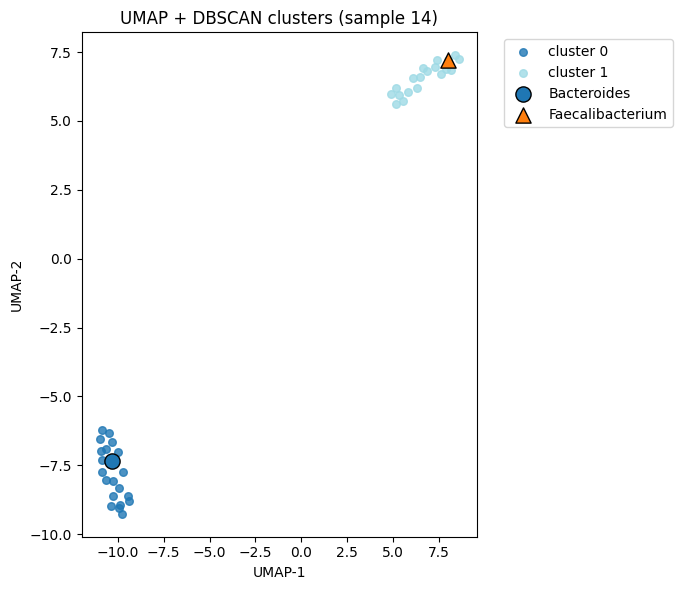

Clusters containing highlighted taxa: [0, 1]
Taxa in those clusters:
Archaea.Methanobacteriota.Methanobacteria.Methanobacteriales.Methanobacteriaceae.Methanobrevibacter
Bacteria.Actinomycetota.Actinobacteria.Actinomycetales.Actinomycetaceae.Mobiluncus
Bacteria.Actinomycetota.Actinobacteria.Mycobacteriales.NA.NA
Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Coriobacteriaceae.Collinsella
Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelatoclostridiaceae.Erysipelotrichaceae UCG-003
Bacteria.Bacillota.Bacilli.Lactobacillales.Streptococcaceae.Streptococcus
Bacteria.Bacillota.Clostridia.Clostridia UCG-014.Incertae Sedis.Incertae Sedis
Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Agathobacter
Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Dorea
Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.NA
Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.probable genus 10
Bacteria.Bacillota.Clostridia.NA.NA.NA
Bacteria.Bacillota.Clostr

In [69]:
res = cluster_and_plot_one_sample(
    outputs=outputs,
    embeddings_dict=embeddings_dict,
    vocab=vocab,
    bacteroides_mask=bacteroides_mask,
    faecali_mask=faecali_mask,
    sample_idx=14,
    eps=0.6,
    min_samples=5,
    X=dtest_filtered.X,         # optional
    drop_zero_count=True,       # optional
)

print("Clusters containing highlighted taxa:", res["highlight_clusters"])
print("Taxa in those clusters:")
print("\n".join(res["taxa_in_highlight_clusters"][:50]))


In [57]:
res['all_clusters']

{0: ['Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Coriobacteriaceae.Collinsella',
  'Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelatoclostridiaceae.Erysipelotrichaceae UCG-003',
  'Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Agathobacter',
  'Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Anaerostipes',
  'Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Coprococcus',
  'Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Dorea',
  'Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Fusicatenibacter',
  'Bacteria.Bacillota.Clostridia.NA.NA.NA',
  'Bacteria.Bacillota.Clostridia.Oscillospirales.Oscillospiraceae.UCG-002',
  'Bacteria.Bacillota.Clostridia.Oscillospirales.Ruminococcaceae.Faecalibacterium',
  'Bacteria.Bacillota.Clostridia.Peptostreptococcales-Tissierellales.Anaerovoracaceae.NA',
  'Bacteria.Bacillota.Clostridia.Peptostreptococcales-Tissierellales.Anaerovoracaceae.S5-A14a',
  'Bacteria.Bacillo